# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/checker_timestamp.csv', header=None, names=['timestamp'], skiprows=1)
print(df.head()) 
print(df.dtypes)  
df['timestamp'] = pd.to_datetime(df['timestamp'])

                    timestamp
0  2020-04-17 05:19:02.744528
1  2020-04-17 05:22:35.249331
2  2020-04-17 05:22:45.549397
3  2020-04-17 05:34:14.691200
4  2020-04-17 05:34:24.422370
timestamp    object
dtype: object


In [3]:
df['date'] = df['timestamp'].dt.date

In [4]:
df['is_weekend'] = df['timestamp'].dt.weekday >= 5

In [5]:
df['is_am'] = df['timestamp'].dt.hour < 12
daily_counts = df.groupby('date').agg(
    am=('is_am', 'sum'),
    pm=('is_am', lambda x: len(x) - sum(x))
).reset_index()

In [6]:
daily_counts['weekday'] = pd.to_datetime(daily_counts['date']).dt.weekday
daily_counts['target'] = daily_counts['weekday'].apply(
    lambda x: 'weekend' if x >= 5 else 'working_day'
)

In [7]:
df_final = daily_counts[['date', 'am', 'pm', 'target']].copy()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   3207 non-null   datetime64[ns]
 1   date        3207 non-null   object        
 2   is_weekend  3207 non-null   bool          
 3   is_am       3207 non-null   bool          
dtypes: bool(2), datetime64[ns](1), object(1)
memory usage: 56.5+ KB


In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    35 non-null     object
 1   am      35 non-null     int64 
 2   pm      35 non-null     int64 
 3   target  35 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.2+ KB


## 2. Exploratory analysis

- Создан график, где `x` - это am, `y` - pm, каждая точка - это день, рабочие дни и выходные должны быть разного цвета.

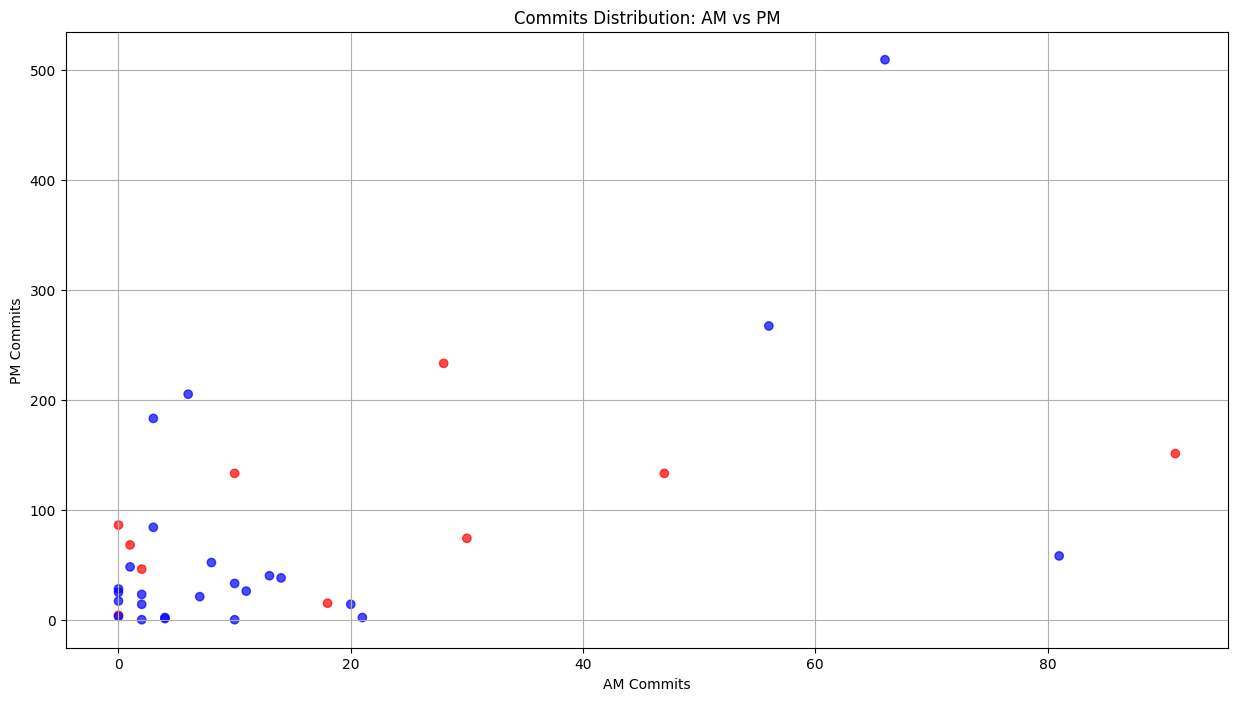

In [10]:
plt.figure(figsize=(15, 8))
colors = df_final['target'].map({
    'weekend': 'red', 
    'working_day': 'blue'
})
plt.scatter(df_final['am'], df_final['pm'], c=colors, alpha=0.7)
plt.xlabel('AM Commits')
plt.ylabel('PM Commits')
plt.title('Commits Distribution: AM vs PM')
plt.grid(True)
plt.show()

Нелегко классифицировать дни, используя только утренние и вечерние коммиты. 
Рабочие дни и выходные имеют перекрывающиеся шаблоны коммитов, что затрудняет четкое разделение.

## 3. Logistic regression

In [11]:
X = df_final[['am', 'pm']]
le = LabelEncoder()
y = le.fit_transform(df_final['target']) 

# Train model
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X, y)

# Make predictions
df_final['predict'] = le.inverse_transform(model.predict(X))

# Save results
df_final.to_csv('../data/am_pm.csv', index=False)

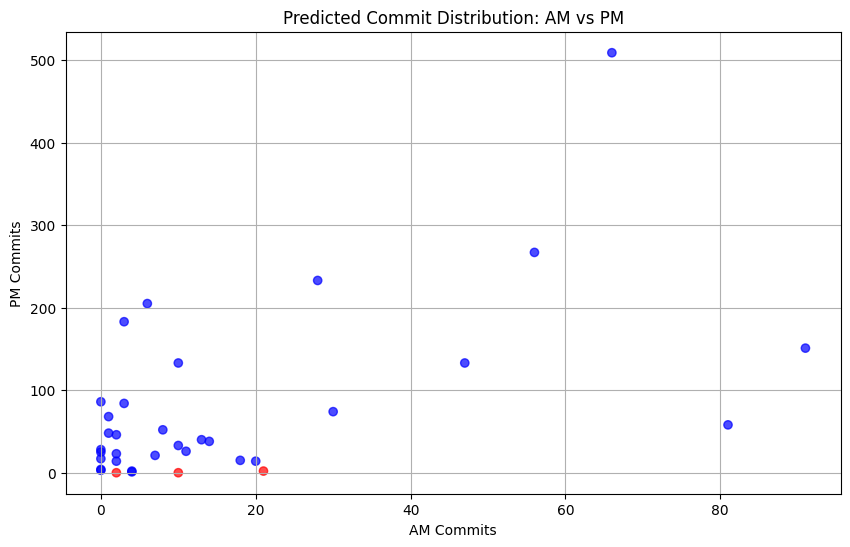

In [12]:
plt.figure(figsize=(10, 6))
colors = df_final['predict'].map({
    'weekend': 'red', 
    'working_day': 'blue'
})
plt.scatter(df_final['am'], df_final['pm'], c=colors, alpha=0.7)
plt.xlabel('AM Commits')
plt.ylabel('PM Commits')
plt.title('Predicted Commit Distribution: AM vs PM')
plt.grid(True)
plt.show()

Модель с трудом точно классифицирует выходные и рабочие дни, 
со множеством неправильно классифицированных точек в перекрывающихся областях.

## 4. Evaluation

In [13]:
y_true = df_final['target']
y_pred = df_final['predict']
accuracy = accuracy_score(y_true, y_pred)

# Calculate naive accuracy 
majority_class = df_final['target'].mode()[0]
naive_accuracy = accuracy_score(y_true, [majority_class]*len(y_true))

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Naive Accuracy: {naive_accuracy:.4f}")

Model Accuracy: 0.6286
Naive Accuracy: 0.7143


Точность модели лишь незначительно лучше, чем у наивного классификатора.